## Fig 3

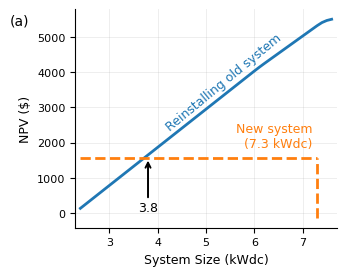

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User inputs
# -----------------------------
csv_name = "01_Resi_SystemSize_vs_NPV.csv"
newsystem_NPV = 1573  # orange reference NPV ($)
new_system_size_kwdc = None  # <-- set to a number (e.g., 7.5) if you want the vertical dashed orange line

# Publication-ish sizing: left panel of a 2-panel figure
FIGSIZE = (3.35, 2.65)  # inches (good for 2 subfigures across a page)
DPI = 600

# -----------------------------
# Helpers
# -----------------------------
def pick_xy_from_csv(df: pd.DataFrame):
    """
    Try to infer x,y columns robustly:
      - If columns include something like 'size' and 'npv', use those
      - Else use first two numeric columns
    """
    cols = [c.lower() for c in df.columns]
    # heuristic names
    x_candidates = [c for c in df.columns if "size" in c.lower() or "kw" in c.lower()]
    y_candidates = [c for c in df.columns if "npv" in c.lower()]

    if x_candidates and y_candidates:
        xcol = x_candidates[0]
        ycol = y_candidates[0]
        x = pd.to_numeric(df[xcol], errors="coerce").to_numpy()
        y = pd.to_numeric(df[ycol], errors="coerce").to_numpy()
        return x, y, xcol, ycol

    # fallback: first two numeric columns
    num_df = df.apply(pd.to_numeric, errors="coerce")
    numeric_cols = [c for c in num_df.columns if num_df[c].notna().sum() > 0]
    if len(numeric_cols) < 2:
        raise ValueError("Could not infer x/y columns. Please rename columns to include 'size' and 'npv' or ensure two numeric columns exist.")
    xcol, ycol = numeric_cols[0], numeric_cols[1]
    x = num_df[xcol].to_numpy()
    y = num_df[ycol].to_numpy()
    return x, y, xcol, ycol

def interpolate_x_at_y(x, y, y_target):
    """
    Finds x where y crosses y_target using linear interpolation.
    Returns None if no crossing is found.
    Assumes x is increasing (or will sort).
    """
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if x.size < 2:
        return None

    # sort by x
    order = np.argsort(x)
    x, y = x[order], y[order]

    # find crossing segment
    diff = y - y_target
    s = np.sign(diff)
    # indices where sign changes (crossing)
    idx = np.where(s[:-1] * s[1:] <= 0)[0]
    if idx.size == 0:
        return None

    i = idx[0]
    x0, x1 = x[i], x[i+1]
    y0, y1 = y[i], y[i+1]
    if y1 == y0:
        return float((x0 + x1) / 2)
    return float(x0 + (y_target - y0) * (x1 - x0) / (y1 - y0))

def text_along_line(ax, x, y, text, x_at=None, fontsize=9, xpo = 0, ypo = 0, **kwargs):
    """
    Places text rotated to match the local slope of the line.
    If x_at is None, uses the midpoint of the x-range.
    Rotation is computed in display coordinates for accuracy.
    """
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    order = np.argsort(x)
    x, y = x[order], y[order]

    if x_at is None:
        x_at = 0.6 * (x.min() + x.max())  # slightly right of center
    # find nearest segment around x_at
    j = np.searchsorted(x, x_at)
    j = np.clip(j, 1, len(x)-1)

    x0, y0 = x[j-1], y[j-1]
    x1, y1 = x[j], y[j]

    # compute rotation angle in screen coords
    p0 = ax.transData.transform((x0, y0))
    p1 = ax.transData.transform((x1, y1))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))

    # position text slightly above the line
    xt = x0 + 0.5*(x1-x0) + xpo
    yt = y0 + 0.5*(y1-y0) + ypo
    
    
    ax.text(
        xt, yt, text,
        rotation=angle, rotation_mode="anchor",
        ha="center", va="bottom",
        fontsize=fontsize,
        color='tab:blue',
        **kwargs
    )

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(csv_name)
x, y, xcol, ycol = pick_xy_from_csv(df)

# clean & sort
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]
order = np.argsort(x)
x, y = x[order], y[order]

# intersection point (where blue meets orange)
x_star = interpolate_x_at_y(x, y, newsystem_NPV)

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

# blue line (dashed)
ax.plot(x, y, linewidth=2.0, label="Reinstalling old-system")

# orange reference (dashed)
#ax.axhline(newsystem_NPV, linestyle="--", linewidth=2.0, color='tab:orange', label="New System (reference)")

# optional vertical orange line at new system size
if new_system_size_kwdc is not None:
    ax.vlines(new_system_size_kwdc, ymin=ax.get_ylim()[0], ymax=newsystem_NPV,
              linestyles="--", linewidth=2.0)

# arrow to intersection (if it exists)
x_star = 3.8  # kWdc crossover (fixed, as in paper)
y_star = newsystem_NPV

#arrow_length = 0.12 * (y.max() - y.min())
arrow_length = 1200

ax.annotate(
    "",
    xy=(x_star, y_star),
    xytext=(x_star, y_star - arrow_length),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.4,
        color="black"
    )
)

ax.text(
    x_star,
    ax.get_ylim()[0] + 0.02 * (y.max() - y.min()),
    "3.8",
    ha="center",
    va="bottom",
    fontsize=9
)

# Labels
ax.set_xlabel("System Size (kWdc)")
ax.set_ylabel("NPV ($)")





new_system_size_kwdc = 7.3

ax.hlines(
    y=newsystem_NPV,
    xmin=x.min(),
    xmax=new_system_size_kwdc,
    linestyles="--",
    linewidth=2.0,
    color="tab:orange"
)


ax.vlines(
    new_system_size_kwdc,
    ymin=ax.get_ylim()[0],
    ymax=newsystem_NPV,
    linestyles="--",
    linewidth=2.0,
    color="tab:orange"
)

# REMOVE?
ax.text(
    new_system_size_kwdc - 0.1,
    newsystem_NPV + 0.04 * (y.max() - y.min()),
    "New system\n(7.3 kWdc)",
    ha="right",
    va="bottom",
    fontsize=9,
    color="tab:orange"
)
"""
# Option B
ax.text(
    x.min() + 0.45*(x.max()-x.min()),
    newsystem_NPV + 0.02*(y.max()-y.min()),
    "New System (reference)",
    fontsize=9, va="bottom"
)
"""

# Clean style similar to paper figures
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.25, linewidth=0.6)

# Reasonable bounds / padding
ax.margins(x=0.02, y=0.05)


# Subfigure label "(a)"
#ax.text(0.02, 0.98, "(a)", transform=ax.transAxes, ha="left", va="top", fontsize=10)
ax.text(-0.25, 0.98, "(a)", transform=ax.transAxes, ha="left", va="top", fontsize=10)

# Put text along the blue line (like your example)
text_along_line(ax, x, y, "Reinstalling old system", xpo=-0.5, ypo=-400, fontsize=9)

# Export (both raster + vector)
fig.savefig("Fig_subA_systemsize_vs_npv.png", dpi=DPI, bbox_inches="tight")
fig.savefig("Fig_subA_systemsize_vs_npv.pdf", bbox_inches="tight")

plt.show()


# Fig 01b_Resi_SystemSize_vs_PaybackPeriod

In [4]:
var_df = pd.read_csv("03_npv_heatmap_variable_cost.csv")


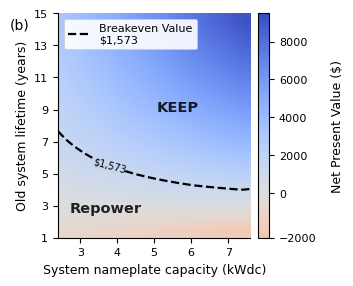

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

# -----------------------------
# User inputs
# -----------------------------
newsystem_NPV = 1573
panel_label = "(b)"
FIGSIZE = (3.45, 2.75)
DPI = 600
INTERP = "bilinear"

# Keep color mapping fixed (as you liked)
TRUE_VMIN = -8000
TRUE_VMAX = 9500

# Crop what is SHOWN on the colorbar (mapping unchanged)
CBAR_DISPLAY_MIN = -2000
CBAR_DISPLAY_MAX = 9500
CBAR_TICKS = [-2000, 0, 2000, 4000, 6000, 8000]

# X ticks to match your other figure
X_TICK_VALS = [3, 4, 5, 6, 7]

# Breakeven contour style
BREAKEVEN_LS = "--"
BREAKEVEN_LW = 1.6
BREAKEVEN_COLOR = "black"

# -----------------------------
# Build pivot table
# -----------------------------
plot_df = var_df.pivot(
    index="Analysis period (years)",
    columns="System nameplate capacity (kWdc)",
    values="NPV Net present value ($)"
).sort_index(axis=0).sort_index(axis=1)

plot_df.index = pd.to_numeric(plot_df.index, errors="coerce")
plot_df.columns = pd.to_numeric(plot_df.columns, errors="coerce")
plot_df = plot_df.sort_index().sort_index(axis=1)

Z = plot_df.to_numpy()
x_vals = plot_df.columns.to_numpy()
y_vals = plot_df.index.to_numpy()

# -----------------------------
# Figure style
# -----------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

# -----------------------------
# Colormap normalization (fixed mapping)
# -----------------------------
norm = TwoSlopeNorm(vmin=TRUE_VMIN, vcenter=0.0, vmax=TRUE_VMAX)

# -----------------------------
# Smooth heatmap
# -----------------------------
im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    cmap="coolwarm_r",
    norm=norm,
    interpolation=INTERP,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
)

# -----------------------------
# Overlay breakeven CONTOUR (NPV = 1573)
# -----------------------------
X, Y = np.meshgrid(x_vals, y_vals)  # same shape as Z (rows=y, cols=x)
cs = ax.contour(
    X, Y, Z,
    levels=[newsystem_NPV],
    colors=BREAKEVEN_COLOR,
    linewidths=BREAKEVEN_LW,
    linestyles=BREAKEVEN_LS
)

# Optional: label the contour inline (comment out if you don't want it)
ax.clabel(cs, fmt={newsystem_NPV: f"${newsystem_NPV:,}"}, inline=True, fontsize=7)

# -----------------------------
# Axes labels & ticks
# -----------------------------
ax.set_xlabel("System nameplate capacity (kWdc)")
ax.set_ylabel("Old system lifetime (years)")

xt = [t for t in X_TICK_VALS if (t >= x_vals.min() and t <= x_vals.max())]
ax.set_xticks(xt)
ax.set_xticklabels([str(t) for t in xt])

yt = np.arange(1, 16, 2)
yt = [t for t in yt if (t >= y_vals.min() and t <= y_vals.max())]
ax.set_yticks(yt)
ax.set_yticklabels([str(int(t)) for t in yt])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel label
ax.text(-0.25, 0.98, panel_label, transform=ax.transAxes,
        ha="left", va="top", fontsize=10)

# -----------------------------
# Colorbar (cropped display only)
# -----------------------------
cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.04)
cbar.set_label("Net Present Value ($)", labelpad=10)
cbar.ax.set_ylim(CBAR_DISPLAY_MIN, CBAR_DISPLAY_MAX)  # crop visible portion
cbar.set_ticks(CBAR_TICKS)
cbar.ax.tick_params(labelsize=8)

# -----------------------------
# Legend entry for the contour line
# -----------------------------
proxy = Line2D([0], [0], color=BREAKEVEN_COLOR, lw=BREAKEVEN_LW, ls=BREAKEVEN_LS,
               label=f"Breakeven Value\n${newsystem_NPV:,}")
leg = ax.legend(handles=[proxy], loc="upper left", frameon=True, fontsize=8)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.9)
leg.get_frame().set_linewidth(0.6)

# -----------------------------
# Region labels
# -----------------------------
ax.text(0.25, 0.13, "Repower",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=10.5, fontweight="bold", alpha=0.85)

ax.text(0.62, 0.58, "KEEP",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=10.5, fontweight="bold", alpha=0.85)

# -----------------------------
# Save
# -----------------------------
fig.savefig("Fig_heatmap_npv_variable_cost_contour.png", dpi=DPI, bbox_inches="tight")
fig.savefig("Fig_heatmap_npv_variable_cost_contour.pdf", bbox_inches="tight")

plt.show()


## Fig 3b

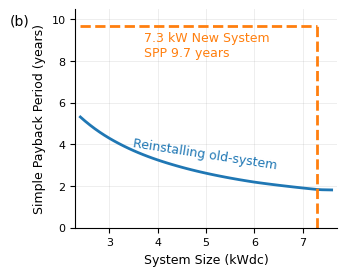

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
csv_name = "01b_Resi_SystemSize_vs_PaybackPeriod.csv"

analysis_period_years = 8
new_system_payback_years = 9.7
new_system_size_kwdc = 7.3

PANEL_LABEL = "(b)"
FIGSIZE = (3.35, 2.65)
DPI = 600

# -----------------------------
# Helper: text along line
# -----------------------------
def text_along_line(ax, x, y, text, x_at=None, fontsize=9, xpo=0.0, ypo=0.0):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    order = np.argsort(x)
    x, y = x[order], y[order]

    if x.size < 2:
        return

    if x_at is None:
        x_at = 0.6 * (x.min() + x.max())

    j = np.searchsorted(x, x_at)
    j = np.clip(j, 1, len(x) - 1)

    x0, y0 = x[j - 1], y[j - 1]
    x1, y1 = x[j], y[j]

    # rotation in display coords
    p0 = ax.transData.transform((x0, y0))
    p1 = ax.transData.transform((x1, y1))
    angle = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))

    xt = x0 + 0.5 * (x1 - x0) + xpo
    yt = y0 + 0.5 * (y1 - y0) + ypo

    ax.text(
        xt, yt, text,
        rotation=angle, rotation_mode="anchor",
        ha="center", va="bottom",
        fontsize=fontsize,
        color="tab:blue"
    )

# -----------------------------
# Load + filter data
# -----------------------------
df = pd.read_csv(csv_name)

def find_col(df, key):
    for c in df.columns:
        if key.lower() in c.lower():
            return c
    raise ValueError(f"Could not find column containing '{key}'")

xcol = find_col(df, "System nameplate capacity")
acol = find_col(df, "Analysis period")
ycol = find_col(df, "Payback")

df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
df[acol] = pd.to_numeric(df[acol], errors="coerce")
df[ycol] = pd.to_numeric(df[ycol], errors="coerce")

df8 = (
    df.loc[df[acol] == analysis_period_years]
      .dropna(subset=[xcol, ycol])
      .sort_values(xcol)
)

x = df8[xcol].to_numpy()
y = df8[ycol].to_numpy()

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

# Blue line
ax.plot(x, y, linewidth=2.0, color="tab:blue")

# --- Force y-axis to start at 0 so the vertical orange line reaches the bottom axis ---
y_bottom = 0.0
y_top = max(np.nanmax(y), new_system_payback_years) * 1.08
ax.set_ylim(y_bottom, y_top)

# --- Orange dashed NEW SYSTEM reference ---
# Horizontal (ends at 7.3)
ax.hlines(
    y=new_system_payback_years,
    xmin=np.nanmin(x),
    xmax=new_system_size_kwdc,
    linestyles="--",
    linewidth=2.0,
    color="tab:orange"
)

# Vertical (goes up from the bottom axis)
ax.vlines(
    x=new_system_size_kwdc,
    ymin=y_bottom,
    ymax=new_system_payback_years,
    linestyles="--",
    linewidth=2.0,
    color="tab:orange"
)

# Label for orange line (your wording/placement)
ax.text(
    np.nanmin(x) + 0.35 * (np.nanmax(x) - np.nanmin(x))-0.5,
    new_system_payback_years + 0.02 * (np.nanmax(y) - np.nanmin(y)) - 1.7,
    "7.3 kW New System\nSPP 9.7 years",
    color="tab:orange",
    fontsize=9,
    ha="left",
    va="bottom"
)

# Text along the blue line (your placement)
text_along_line(
    ax, x, y,
    "Reinstalling old-system",
    xpo=-1.0, ypo=1,
    fontsize=9
)

# Labels
ax.set_xlabel("System Size (kWdc)")
ax.set_ylabel("Simple Payback Period (years)")

# Styling to match subfigure (a)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, alpha=0.25, linewidth=0.6)
ax.margins(x=0.02, y=0.08)

# Subfigure label
ax.text(-0.25, 0.98, PANEL_LABEL, transform=ax.transAxes,
        ha="left", va="top", fontsize=10)

# Save
fig.savefig("Fig_subB_systemsize_vs_payback.png", dpi=DPI, bbox_inches="tight")
fig.savefig("Fig_subB_systemsize_vs_payback.pdf", bbox_inches="tight")
plt.show()


## Fig 03 NPV Heatmap Variable Cost

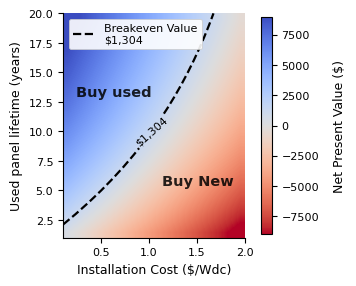

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

# -----------------------------
# User inputs
# -----------------------------
csv_name = "04_2nd_life_npv_no_itc.csv"
newsystem_NPV = 1304

# Match previous heatmap panel formatting/sizing
panel_label = ""          # e.g., "(c)" if needed
FIGSIZE = (3.45, 2.75)    # SAME as your previous heatmap
DPI = 600
INTERP = "bilinear"       # smooth like your other "final" heatmap

# Colormap mapping (keep consistent style)
TRUE_VMIN = -9000
TRUE_VMAX = 9000
CBAR_TICKS = [-7500, -5000, -2500, 0, 2500, 5000, 7500]

# Breakeven contour style (match other figure)
BREAKEVEN_LS = "--"
BREAKEVEN_LW = 1.6
BREAKEVEN_COLOR = "black"

# -----------------------------
# Helpers
# -----------------------------
def find_col_contains(df, candidates):
    for c in df.columns:
        cl = c.lower()
        if any(s.lower() in cl for s in candidates):
            return c
    raise ValueError(f"Could not find column containing any of: {candidates}\nColumns: {list(df.columns)}")

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(csv_name)

xcol = find_col_contains(df, ["installation cost", "$/wdc", "$/w", "install cost", "cost"])
ycol = find_col_contains(df, ["used panel lifetime", "panel lifetime", "lifetime", "years"])
zcol = find_col_contains(df, ["npv", "net present value"])

df[xcol] = pd.to_numeric(df[xcol], errors="coerce")
df[ycol] = pd.to_numeric(df[ycol], errors="coerce")
df[zcol] = pd.to_numeric(df[zcol], errors="coerce")
df = df.dropna(subset=[xcol, ycol, zcol])

plot_df = (
    df.pivot(index=ycol, columns=xcol, values=zcol)
      .sort_index(axis=0)
      .sort_index(axis=1)
)

Z = plot_df.to_numpy()
x_vals = plot_df.columns.to_numpy()
y_vals = plot_df.index.to_numpy()

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

# Diverging normalization centered at 0
norm = TwoSlopeNorm(vmin=TRUE_VMIN, vcenter=0.0, vmax=TRUE_VMAX)

# Smooth heatmap
im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    cmap="coolwarm_r",
    norm=norm,
    interpolation=INTERP,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
)

# Breakeven isocontour (NPV = 1304), dashed like your other heatmap
X, Y = np.meshgrid(x_vals, y_vals)
cs = ax.contour(
    X, Y, Z,
    levels=[newsystem_NPV],
    colors=BREAKEVEN_COLOR,
    linewidths=BREAKEVEN_LW,
    linestyles=BREAKEVEN_LS
)

# Inline $ label on contour (match your prior figure style)
ax.clabel(
    cs,
    fmt={newsystem_NPV: f"${newsystem_NPV:,}"},
    inline=True,
    fontsize=8
)

# Axes labels
ax.set_xlabel("Installation Cost ($/Wdc)")
ax.set_ylabel("Used panel lifetime (years)")

# Clean spines (match other figures)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional panel label
if panel_label:
    ax.text(-0.25, 0.98, panel_label, transform=ax.transAxes,
            ha="left", va="top", fontsize=10)

# Region labels (scaled to fit the smaller panel size)
ax.text(0.28, 0.65, "Buy used", transform=ax.transAxes,
        ha="center", va="center", fontsize=10.5, fontweight="bold", alpha=0.85)

ax.text(0.74, 0.25, "Buy New", transform=ax.transAxes,
        ha="center", va="center", fontsize=10.5, fontweight="bold", alpha=0.85)

# Legend (contour proxy)
proxy = Line2D([0], [0], color=BREAKEVEN_COLOR, lw=BREAKEVEN_LW, ls=BREAKEVEN_LS,
               label="Breakeven Value\n$1,304")
leg = ax.legend(handles=[proxy], loc="upper left", frameon=True, fontsize=8)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(0.9)
leg.get_frame().set_linewidth(0.6)

# Colorbar (no NPV marker; consistent with your prior figure)
cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.04)
cbar.set_label("Net Present Value ($)", labelpad=10)
cbar.set_ticks(CBAR_TICKS)
cbar.ax.tick_params(labelsize=8)

# -----------------------------
# Save
# -----------------------------
fig.savefig("Fig_2ndlife_npv_no_itc_smooth_contour.png", dpi=DPI, bbox_inches="tight")
fig.savefig("Fig_2ndlife_npv_no_itc_smooth_contour.pdf", bbox_inches="tight")

plt.show()
